Loaded: (9105, 47)


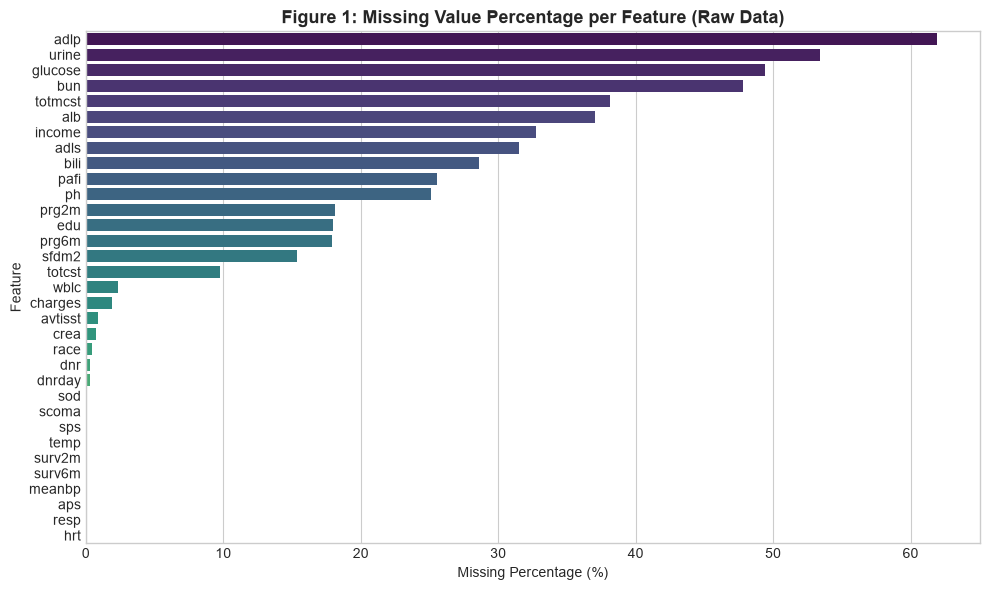

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

raw_df = pd.read_csv("data/raw/support2.csv")
print("Loaded:", raw_df.shape)

# --- Figure 1: Missing values ---
plt.figure(figsize=(10, 6))
missing_pct = (raw_df.isnull().sum() / len(raw_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if not missing_pct.empty:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette='viridis', legend=False)
    plt.title('Figure 1: Missing Value Percentage per Feature (Raw Data)', fontsize=13, fontweight='bold')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


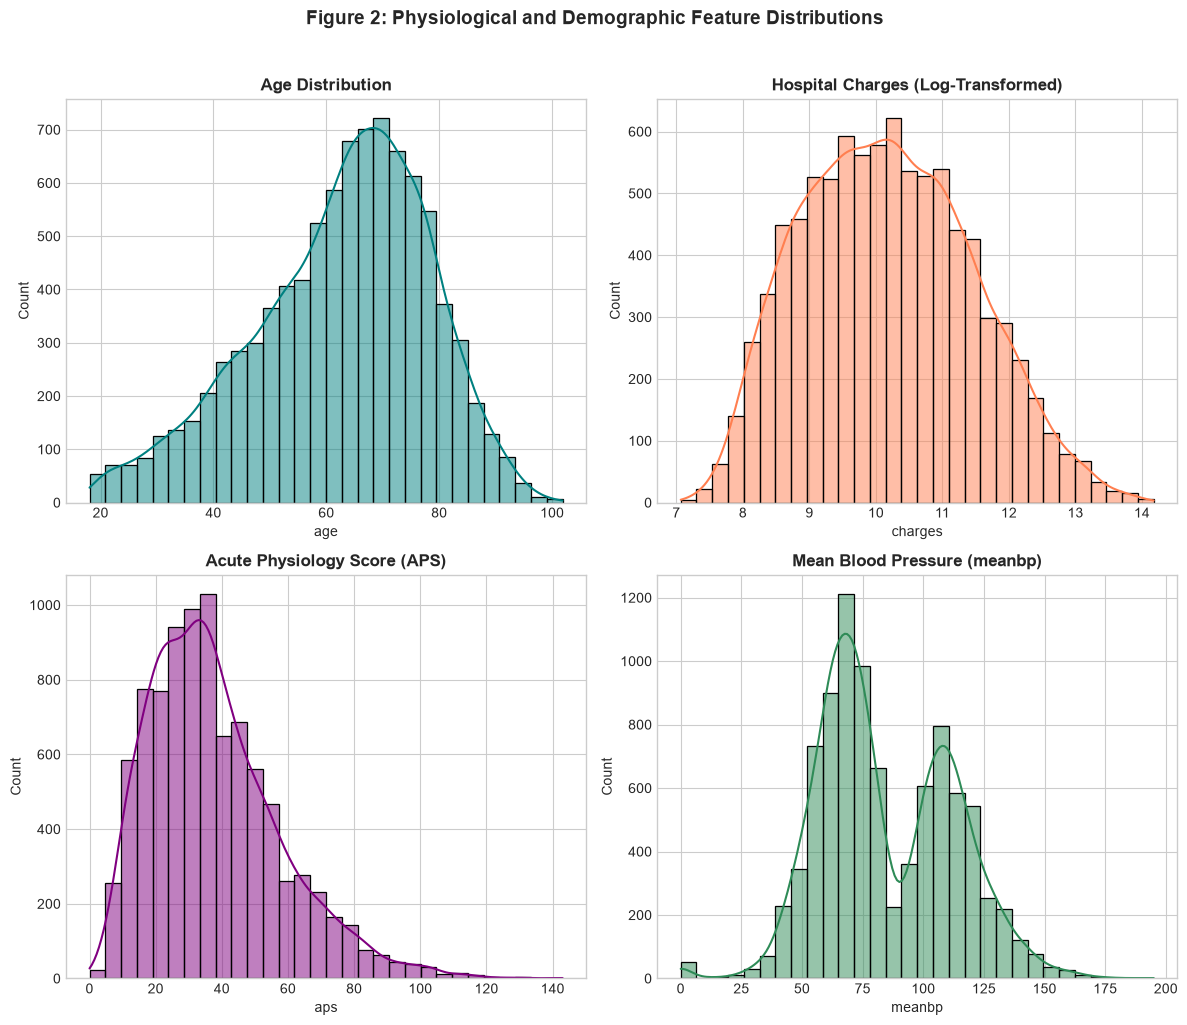

In [2]:
#  Figure 2: Feature distributions 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
if 'age' in raw_df.columns:
    sns.histplot(raw_df['age'].dropna(), kde=True, ax=axes[0, 0], color='teal', bins=30)
    axes[0, 0].set_title('Age Distribution', fontweight='bold')
if 'charges' in raw_df.columns:
    sns.histplot(np.log1p(raw_df['charges'].dropna()), kde=True, ax=axes[0, 1], color='coral', bins=30)
    axes[0, 1].set_title('Hospital Charges (Log-Transformed)', fontweight='bold')
if 'aps' in raw_df.columns:
    sns.histplot(raw_df['aps'].dropna(), kde=True, ax=axes[1, 0], color='purple', bins=30)
    axes[1, 0].set_title('Acute Physiology Score (APS)', fontweight='bold')
if 'meanbp' in raw_df.columns:
    sns.histplot(raw_df['meanbp'].dropna(), kde=True, ax=axes[1, 1], color='seagreen', bins=30)
    axes[1, 1].set_title('Mean Blood Pressure (meanbp)', fontweight='bold')
plt.suptitle('Figure 2: Physiological and Demographic Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


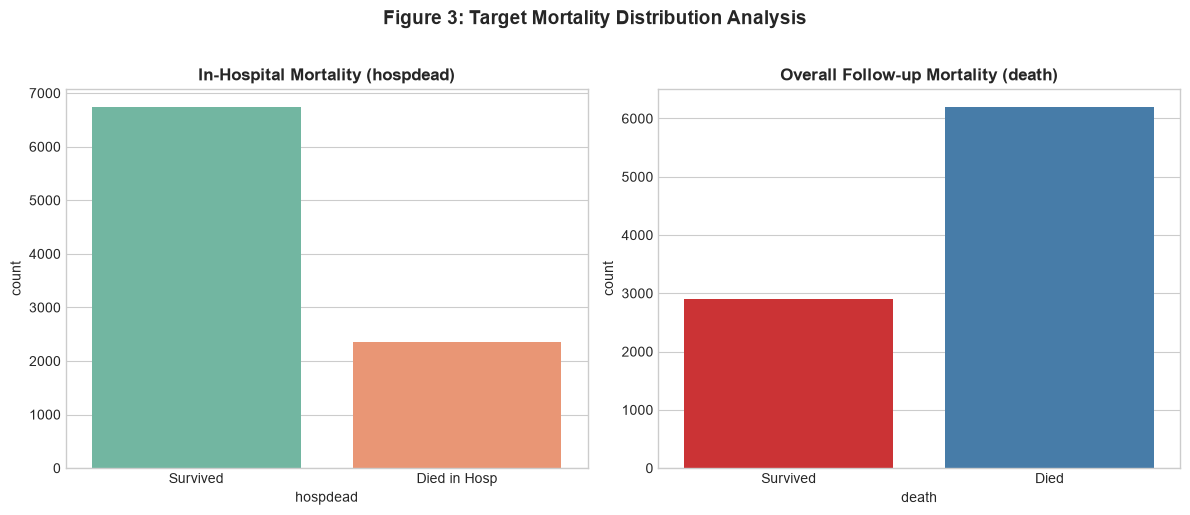

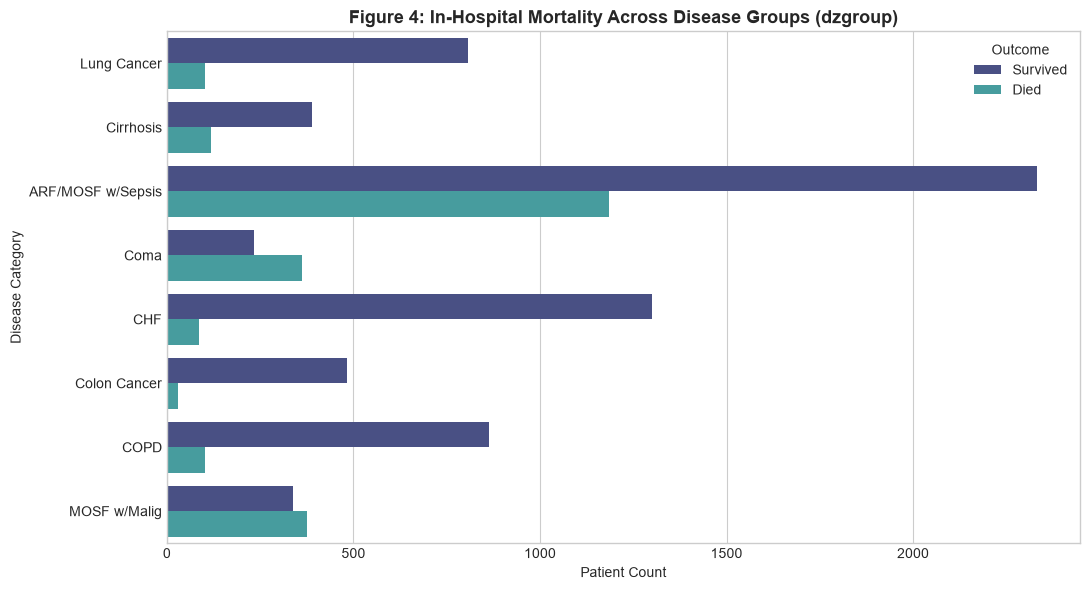

In [4]:
#  Figure 3: Target mortality distributions 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if 'hospdead' in raw_df.columns:
    sns.countplot(x='hospdead', data=raw_df, hue='hospdead', palette='Set2', legend=False, ax=axes[0])
    axes[0].set_title('In-Hospital Mortality (hospdead)', fontweight='bold')
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Survived', 'Died in Hosp'])
if 'death' in raw_df.columns:
    sns.countplot(x='death', data=raw_df, hue='death', palette='Set1', legend=False, ax=axes[1])
    axes[1].set_title('Overall Follow-up Mortality (death)', fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Survived', 'Died'])
plt.suptitle('Figure 3: Target Mortality Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 4: Mortality by disease group ---
if 'dzgroup' in raw_df.columns and 'hospdead' in raw_df.columns:
    plt.figure(figsize=(11, 6))
    sns.countplot(y='dzgroup', hue='hospdead', data=raw_df, palette='mako')
    plt.title('Figure 4: In-Hospital Mortality Across Disease Groups (dzgroup)', fontsize=13, fontweight='bold')
    plt.xlabel('Patient Count')
    plt.ylabel('Disease Category')
    plt.legend(title='Outcome', labels=['Survived', 'Died'])
    plt.tight_layout()
    plt.show()


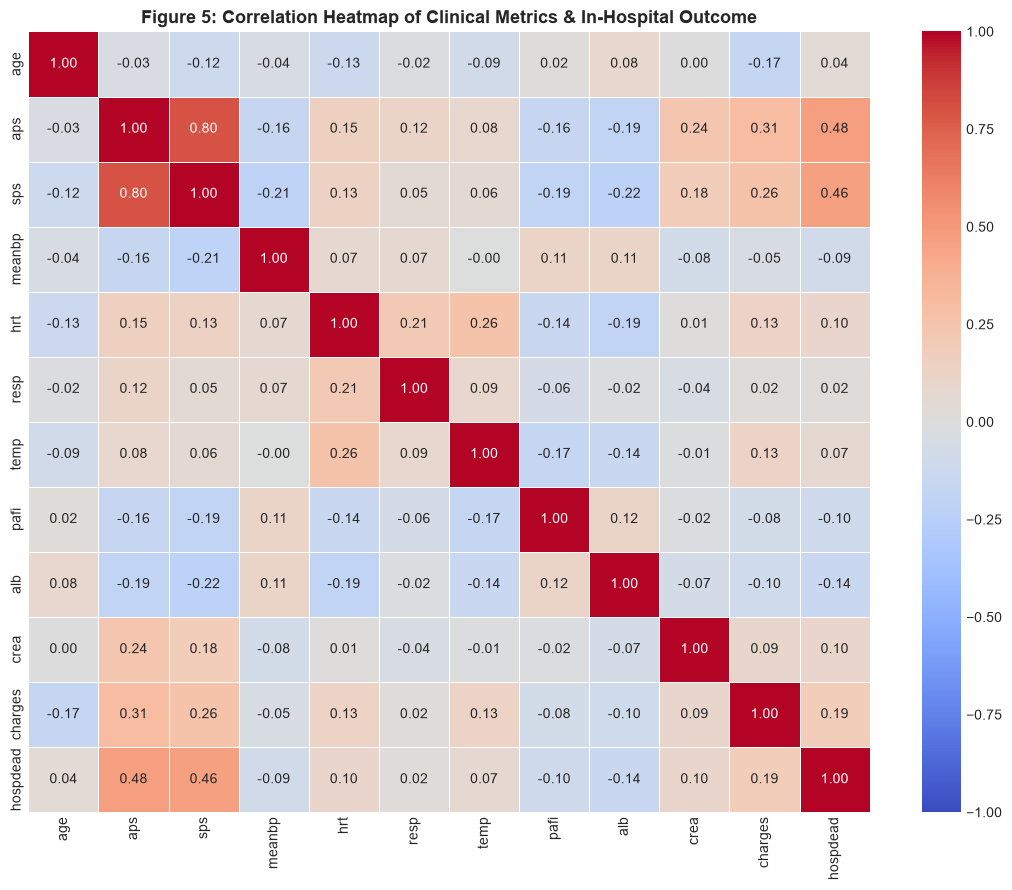

In [5]:
#  Figure 5: Correlation heatmap 
# NOTE: surv2m and surv6m removed here -- these are leakage columns
# (the original study's own survival predictions, not raw measurements)
# and were already excluded in Task 3 for the same reason.
key_vars = ['age', 'aps', 'sps', 'meanbp', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'crea', 'charges', 'hospdead']
avail_vars = [v for v in key_vars if v in raw_df.columns]
if len(avail_vars) > 0:
    plt.figure(figsize=(11, 9))
    corr = raw_df[avail_vars].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    plt.title('Figure 5: Correlation Heatmap of Clinical Metrics & In-Hospital Outcome', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


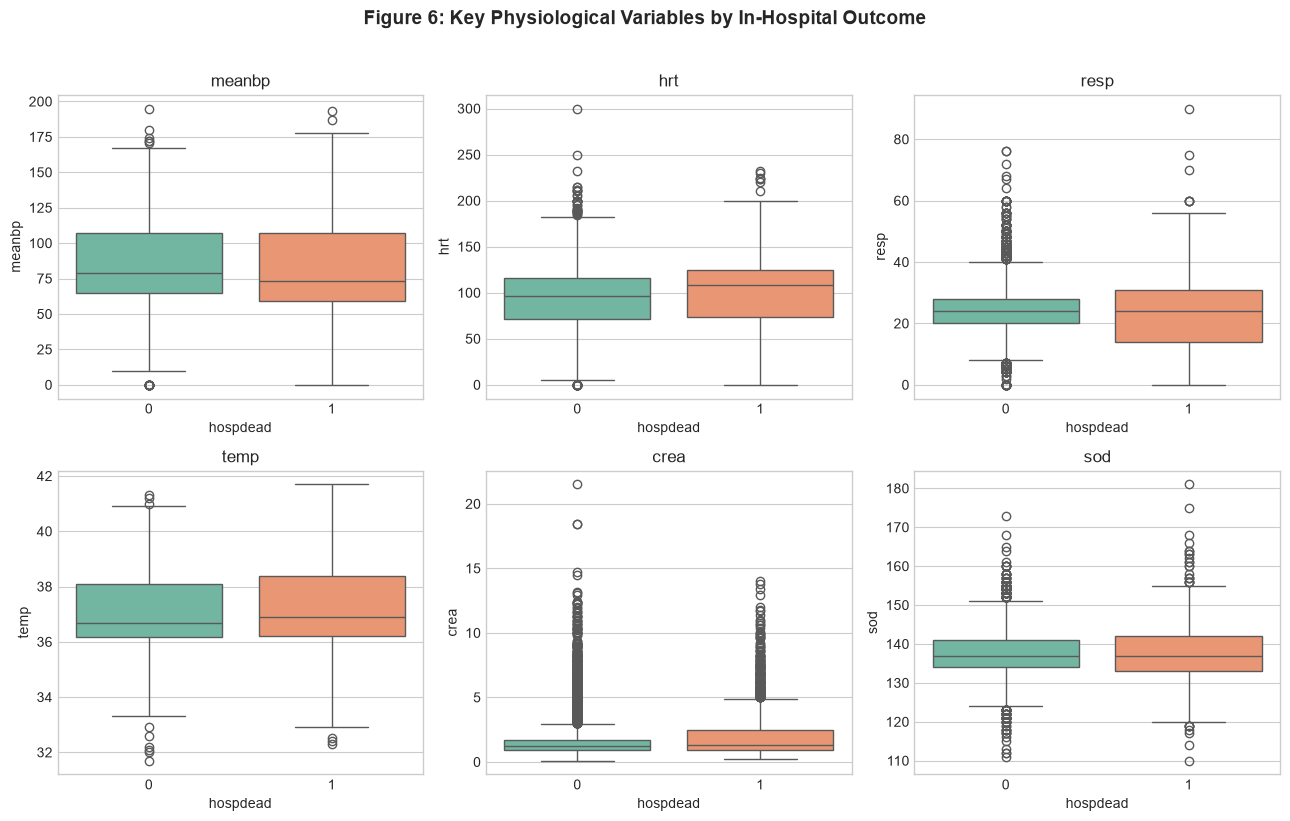

Task 4 Complete: Exploratory Data Analysis and Visualisations generated.


In [6]:
#  Figure 6: Physiology boxplots by outcome 
phys_vars = ['meanbp', 'hrt', 'resp', 'temp', 'crea', 'sod']
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, v in zip(axes.ravel(), phys_vars):
    sns.boxplot(data=raw_df, x='hospdead', y=v, hue='hospdead', ax=ax, palette='Set2', legend=False)
    ax.set_title(v)
plt.suptitle('Figure 6: Key Physiological Variables by In-Hospital Outcome', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Task 4 Complete: Exploratory Data Analysis and Visualisations generated.")
